# <center>Homework 97</center>

## Task 1

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from importlib import reload
import perceptron
from sklearn.metrics import f1_score, accuracy_score

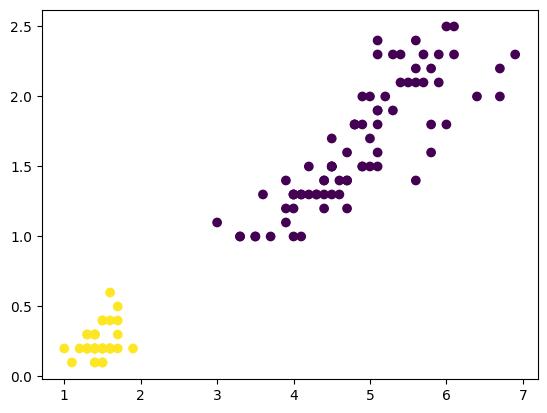

In [100]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Iris setosa

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

In [85]:
X_train.shape
# X_test.shape

(120, 2)

--------------- Custom ---------------
F1: 1.0 acc: 1.0 n_iter: 6
--------------- Original ---------------
F1: 1.0 acc: 1.0 n_iter: 7


(0.0, 8.0)

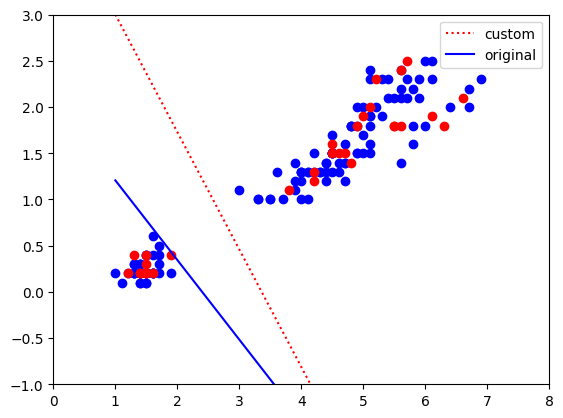

In [101]:
print('--------------- Custom ---------------')
reload(perceptron)
from perceptron import Perceptron

custom = Perceptron(random_state=42).fit(X_train, y_train)
y_test_pred = custom.predict(X_test)
print('F1:', f1_score(y_test, y_test_pred), 'acc:', accuracy_score(y_test, y_test_pred), 'n_iter:', custom.n_iter_)

print('--------------- Original ---------------')
from sklearn.linear_model import Perceptron
org = Perceptron(random_state=42).fit(X_train, y_train)
y_test_pred = org.predict(X_test)
print('F1:', f1_score(y_test, y_test_pred), 'acc:', accuracy_score(y_test, y_test_pred), 'n_iter:', org.n_iter_)


# per_clf = Perceptron(random_state=42)
# per_clf.fit(X, y)
# X_new = [[2, 0.5], [3, 1]]
# y_pred = per_clf.predict(X_new)

plt.scatter(X_train[:, 0], X_train[:, 1], c='b')
plt.scatter(X_test[:, 0], X_test[:, 1], c='r')


x0_min, x0_max = X[:, 0].min(), X[:, 0].max()

c_b, c_w1, c_w2 = custom.theta_.ravel()
c_x1 = np.linspace(x0_min, x0_max, 100)
c_x2 = -(c_w1/c_w2)*c_x1 - c_b/c_w2
plt.plot(c_x1, c_x2, 'r:', label='custom')

o_w1, o_w2 = org.coef_.ravel()
o_b = org.intercept_[0]
o_x1 = np.linspace(x0_min, x0_max, 100)
o_x2 = -(o_w1/o_w2)*o_x1 - o_b/o_w2
plt.plot(o_x1, o_x2, 'b-', label='original')

plt.legend()
plt.ylim(-1, 3)
plt.xlim(0, 8)

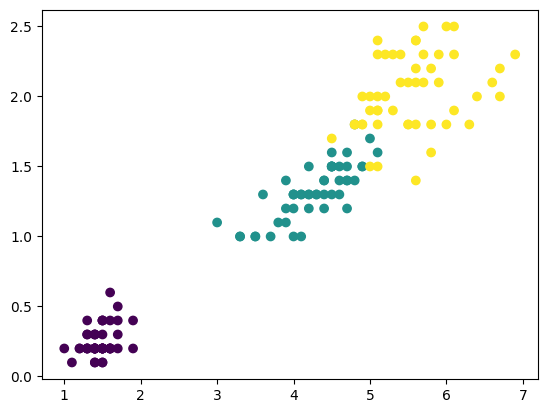

In [104]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True)

plt.scatter(X[:, 0], X[:, 1], c=y)
# plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

In [88]:
len(np.unique(y_test))

3

In [106]:
print('--------------- Custom ---------------')
reload(perceptron)
from perceptron import Perceptron

custom = Perceptron(random_state=42, max_iter=12, tol=0.1).fit(X_train, y_train)
y_test_pred = custom.predict(X_test)
print('F1:', f1_score(y_test, y_test_pred, average='macro'), 'acc:', accuracy_score(y_test, y_test_pred), 'n_iter:', custom.n_iter_)

print('--------------- Original ---------------')
from sklearn.linear_model import Perceptron
org = Perceptron(random_state=42).fit(X_train, y_train)
y_test_pred = org.predict(X_test)
print('F1:', f1_score(y_test, y_test_pred, average='macro'), 'acc:', accuracy_score(y_test, y_test_pred), 'n_iter:', org.n_iter_)

--------------- Custom ---------------
F1: 0.5555555555555555 acc: 0.6666666666666666 n_iter: 12
--------------- Original ---------------
F1: 0.8294970161977835 acc: 0.8333333333333334 n_iter: 12


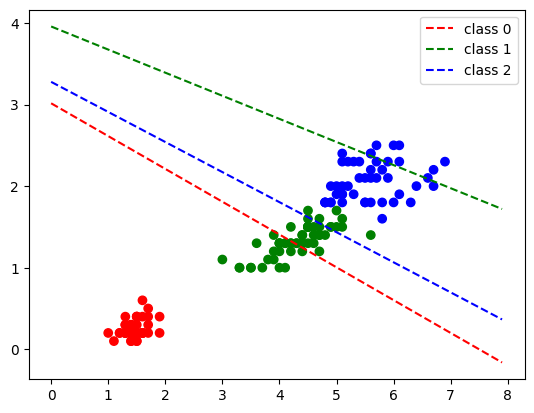

In [97]:
colors = np.array(['r', 'g', 'b'])
plt.scatter(X[:, 0], X[:, 1], c=colors[custom.predict(X)])

x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
c_x1 = np.linspace(x0_min, x0_max, 200)

for i in range(3):
    c_b, c_w1, c_w2 = custom.theta_[i]
    c_x2 = -(c_w1/c_w2) * c_x1 - c_b/c_w2
    plt.plot(c_x1, c_x2, color=colors[i], linestyle='--', label=f'class {i}')

plt.legend()

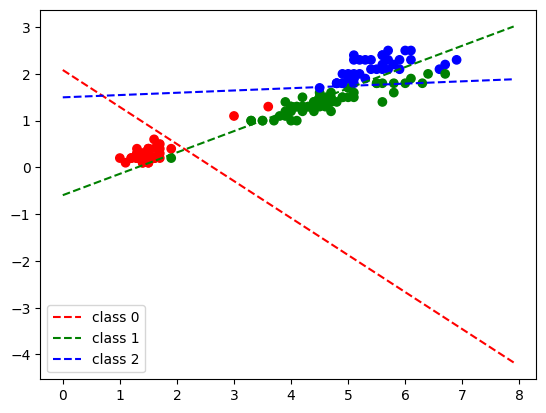

In [98]:
colors = np.array(['r', 'g', 'b'])
plt.scatter(X[:, 0], X[:, 1], c=colors[org.predict(X)])

x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
c_x1 = np.linspace(x0_min, x0_max, 200)

for i in range(3):
    c_w1, c_w2 = org.coef_[i]
    c_b = org.intercept_[i]
    c_x2 = -(c_w1/c_w2) * c_x1 - c_b/c_w2
    plt.plot(c_x1, c_x2, color=colors[i], linestyle='--', label=f'class {i}')

plt.legend()

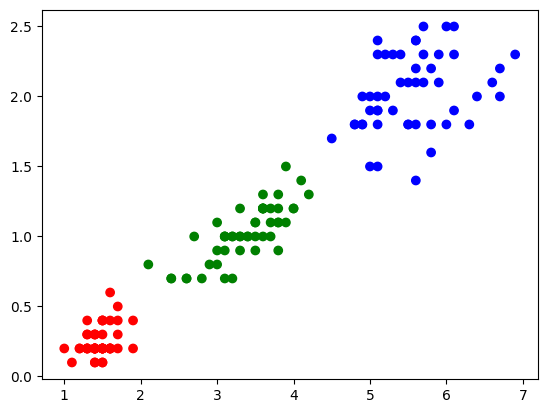

In [91]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
X[y == 1, 0] -= 0.9
X[y == 1, 1] -= 0.3

y = iris.target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True)

colors = np.array(['r', 'g', 'b'])
plt.scatter(X[:, 0], X[:, 1], c=colors[y])

In [92]:
print('--------------- Custom ---------------')
reload(perceptron)
from perceptron import Perceptron

custom = Perceptron(random_state=42, max_iter=200).fit(X_train, y_train)
y_test_pred = custom.predict(X_test)
print('F1:', f1_score(y_test, y_test_pred, average='macro'), 'n_iter:', custom.n_iter_)

print('--------------- Original ---------------')
from sklearn.linear_model import Perceptron
org = Perceptron(random_state=42).fit(X_train, y_train)
y_test_pred = org.predict(X_test)
print('F1:', f1_score(y_test, y_test_pred, average='macro'), 'n_iter:', org.n_iter_)

--------------- Custom ---------------
F1: 1.0 n_iter: 17
--------------- Original ---------------
F1: 0.7212454212454213 n_iter: 15


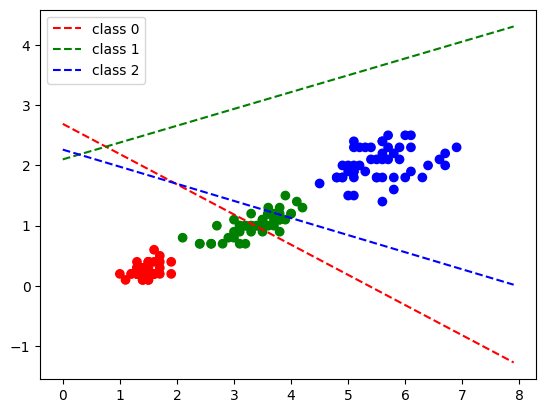

In [93]:
colors = np.array(['r', 'g', 'b'])
plt.scatter(X[:, 0], X[:, 1], c=colors[custom.predict(X)])

x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
c_x1 = np.linspace(x0_min, x0_max, 200)

for i in range(3):
    c_b, c_w1, c_w2 = custom.theta_[i]
    c_x2 = -(c_w1/c_w2) * c_x1 - c_b/c_w2
    plt.plot(c_x1, c_x2, color=colors[i], linestyle='--', label=f'class {i}')

plt.legend()

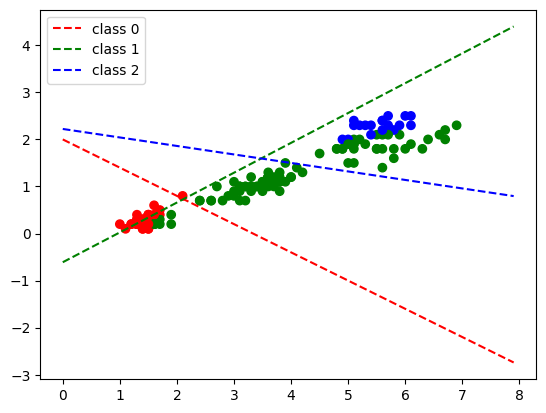

In [94]:
colors = np.array(['r', 'g', 'b'])
plt.scatter(X[:, 0], X[:, 1], c=colors[org.predict(X)])

x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
c_x1 = np.linspace(x0_min, x0_max, 200)

for i in range(3):
    c_w1, c_w2 = org.coef_[i]
    c_b = org.intercept_[i]
    c_x2 = -(c_w1/c_w2) * c_x1 - c_b/c_w2
    plt.plot(c_x1, c_x2, color=colors[i], linestyle='--', label=f'class {i}')

plt.legend()

In [108]:
arr = np.array([4, 5, 1])
np.exp(arr)

array([ 54.59815003, 148.4131591 ,   2.71828183])